# Model 2C, Logistic Regression Experiment 03: Ridge Logistic Regression

This append-only experiment tests whether L2—or ridge—regularization improves Model 2C. It uses Logistic Regression 2C Experiment 02's selected representation: 31 raw-taxi source fields plus a fold-fitted spline of `MINUTES_TO_SCHEDULED_ARRIVAL = CRSElapsedTime - DepDelay - TaxiOut`.

The representation is held fixed. The experiment compares five ridge strengths with and without balanced class weights. Spline knots, imputation, category encoding, scaling, classifier settings, and the operating threshold are learned only from five expanding 2019 folds. The selected design is refitted on all 2019 rows and evaluated once on 2023. No new feature dataset is created, and the 2024 dataset is not loaded.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    make_scorer,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler

AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "ArrDel15"
RANDOM_STATE = 42
N_TIME_SPLITS = 5
N_JOBS = 1
SPLINE_KNOTS = 5
SPLINE_DEGREE = 3

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## Load and validate the shared arrival datasets

The experiment uses the same 2019 training rows and 2023 validation rows as the completed Model 2C experiments.

In [2]:
def find_project_root(start: Path, airport: str, years) -> Path:
    required = [
        Path("data/features") / f"{airport}_{year}_arrivals.csv"
        for year in years
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required feature datasets: {required}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve(), AIRPORT, [TRAIN_YEAR, VALIDATION_YEAR])
TRAIN_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{TRAIN_YEAR}_arrivals.csv"
VALIDATION_DATA_PATH = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{VALIDATION_YEAR}_arrivals.csv"

train_df = pd.read_csv(TRAIN_DATA_PATH, low_memory=False)
validation_df = pd.read_csv(VALIDATION_DATA_PATH, low_memory=False)


def validate_source_frame(frame: pd.DataFrame, year: int, partition: str):
    required = {"FlightDate", "Dest", TARGET}
    missing = sorted(required.difference(frame.columns))
    assert not missing, f"{partition} missing columns: {missing}"
    frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="raise")
    assert frame["FlightDate"].dt.year.eq(year).all()
    assert frame["Dest"].eq(AIRPORT).all()
    assert frame[TARGET].notna().all()
    assert set(frame[TARGET].unique()).issubset({0, 0.0, 1, 1.0})
    return {
        "partition": partition,
        "year": year,
        "start": frame["FlightDate"].min().date(),
        "end": frame["FlightDate"].max().date(),
        "days": frame["FlightDate"].dt.normalize().nunique(),
        "rows": len(frame),
        "delayed_flights": int(frame[TARGET].sum()),
        "delay_rate": frame[TARGET].mean(),
    }


source_summary = pd.DataFrame([
    validate_source_frame(train_df, TRAIN_YEAR, "training"),
    validate_source_frame(validation_df, VALIDATION_YEAR, "external validation"),
]).set_index("partition")
source_summary

,year,start,end,days,rows,delayed_flights,delay_rate
partition,,,,,,,
training,2019,2019-01-01,2019-12-31,365,107354,21784,0.2029
external validation,2023,2023-01-01,2023-12-31,365,109947,27077,0.2463


## Hold the selected Model 2C representation fixed

The only classifier change is L2 rather than L1 regularization. All 31 source fields and the degree-3 schedule-margin spline match Logistic Regression 2C Experiment 02.

In [3]:
CATEGORICAL_FEATURES = ["Reporting_Airline", "Origin"]

MODEL_2A_NUMERIC_FEATURES = [
    "SCHED_DEP_TIME_SIN",
    "SCHED_DEP_TIME_COS",
    "SCHED_ARR_TIME_SIN",
    "SCHED_ARR_TIME_COS",
    "DAY_OF_WEEK_SIN",
    "DAY_OF_WEEK_COS",
    "DAY_OF_YEAR_SIN",
    "DAY_OF_YEAR_COS",
    "IS_WEEKEND",
    "CRSElapsedTime",
    "LOG_DISTANCE",
    "SCHEDULED_SPEED_PROXY",
    "ASPM_THREE_HOUR_SCHEDULED_DEPARTURES",
    "ASPM_THREE_HOUR_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_MINUS_PREVIOUS_TRAFFIC",
    "ASPM_NEXT_MINUS_CURRENT_TRAFFIC",
    "ASPM_MAX_HOURLY_TRAFFIC",
    "HourlyDryBulbTemperature",
    "TEMP_DEWPOINT_SPREAD",
    "LOG_PRECIPITATION",
    "HourlyVisibility",
    "WindX",
    "WindY",
    "ADVERSE_WEATHER",
    "NOAA_AGE_MINUTES",
]
NUMERIC_FEATURES = [
    *MODEL_2A_NUMERIC_FEATURES,
    "DepDelay",
    "TaxiOut",
    "ACTUAL_TAKEOFF_TIME_SIN",
    "ACTUAL_TAKEOFF_TIME_COS",
]
CALCULATED_MARGIN = "MINUTES_TO_SCHEDULED_ARRIVAL"
SOURCE_FEATURES = [*CATEGORICAL_FEATURES, *NUMERIC_FEATURES]
MODEL_COLUMNS = [*SOURCE_FEATURES, CALCULATED_MARGIN]

assert len(SOURCE_FEATURES) == len(set(SOURCE_FEATURES)) == 31
assert len(MODEL_COLUMNS) == 32

required_columns = ["FlightDate", "Dest", "CRSDepTime", TARGET, *SOURCE_FEATURES]
for partition, frame in [("training", train_df), ("external validation", validation_df)]:
    missing = sorted(set(required_columns).difference(frame.columns))
    assert not missing, f"{partition} missing required columns: {missing}"

forbidden_predictors = {
    TARGET,
    "DepTime",
    "DepDelayMinutes",
    "DepDel15",
    "DepartureDelayGroups",
    "WheelsOff",
    "ArrTime",
    "ArrDelay",
    "ArrDelayMinutes",
    "ArrivalDelayGroups",
    "WheelsOn",
    "TaxiIn",
    "ActualElapsedTime",
    "AirTime",
    "Tail_Number",
}
assert not forbidden_predictors.intersection(SOURCE_FEATURES)

pd.Series({
    "saved source fields": len(SOURCE_FEATURES),
    "calculated model-side fields": 1,
    "model inputs before preprocessing": len(MODEL_COLUMNS),
    "categorical source fields": len(CATEGORICAL_FEATURES),
    "numeric source fields": len(NUMERIC_FEATURES),
}, name="Ridge-logistic 2C input design").to_frame()

,Ridge-logistic 2C input design
saved source fields,31
calculated model-side fields,1
model inputs before preprocessing,32
categorical source fields,2
numeric source fields,29


## Calculate the margin and create chronological folds

The row-level margin uses only information known at takeoff. Every learned transformation is fitted separately inside each 2019 training fold.

In [4]:
def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)
    for column in CATEGORICAL_FEATURES:
        frame[column] = frame[column].astype(object)
    for column in NUMERIC_FEATURES:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    frame[CALCULATED_MARGIN] = (
        frame["CRSElapsedTime"] - frame["DepDelay"] - frame["TaxiOut"]
    )
    return frame


train_model_df = prepare_model_frame(train_df)
validation_model_df = prepare_model_frame(validation_df)
X_train = train_model_df[MODEL_COLUMNS].reset_index(drop=True)
X_validation = validation_model_df[MODEL_COLUMNS].reset_index(drop=True)
y_train = train_model_df[TARGET].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)

assert training_dates.max() < validation_dates.min()
assert X_train[CALCULATED_MARGIN].notna().all()
assert X_validation[CALCULATED_MARGIN].notna().all()


def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    unique_days = np.array(sorted(pd.unique(normalized)))
    day_blocks = np.array_split(unique_days, n_splits + 1)
    splits, rows = [], []
    for fold in range(1, n_splits + 1):
        train_days = np.concatenate(day_blocks[:fold])
        heldout_days = day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold,
            "train_rows": len(train_idx),
            "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })
    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(
    training_dates, y_train, N_TIME_SPLITS
)
display(pd.DataFrame({
    "training": X_train[CALCULATED_MARGIN].describe(),
    "external_validation": X_validation[CALCULATED_MARGIN].describe(),
}))
fold_summary

,training,external_validation
count,"107,354.0000","109,947.0000"
mean,178.5130,165.9134
std,113.4119,117.9957
min,"-1,392.0000","-2,266.0000"
25%,97.0000,94.0000
50%,161.0000,148.0000
75%,288.0000,264.0000
max,578.0000,601.0000


,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17776,18725,2019-03-02,2019-03-03,2019-05-02,0.2082,0.1834
2,36501,18153,2019-05-02,2019-05-03,2019-07-02,0.1955,0.2319
3,54654,17703,2019-07-02,2019-07-03,2019-09-01,0.2076,0.2646
4,72357,17650,2019-09-01,2019-09-02,2019-11-01,0.2215,0.1474
5,90007,17347,2019-11-01,2019-11-02,2019-12-31,0.2070,0.1818


## Select ridge strength and class weighting using 2019

`C` is the inverse regularization strength: smaller values apply stronger shrinkage. All ten candidates use the L2 penalty and the same `lbfgs` solver. Mean temporal average precision selects the configuration.

In [5]:
def make_pipeline():
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])
    margin_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        (
            "spline",
            SplineTransformer(
                n_knots=SPLINE_KNOTS,
                degree=SPLINE_DEGREE,
                knots="quantile",
                extrapolation="linear",
                include_bias=False,
            ),
        ),
        ("scaler", StandardScaler()),
    ])
    preprocessor = ColumnTransformer(
        [
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("schedule_margin", margin_pipeline, [CALCULATED_MARGIN]),
        ],
        remainder="drop",
    )
    classifier = LogisticRegression(
        l1_ratio=0.0,
        solver="lbfgs",
        max_iter=5_000,
        random_state=RANDOM_STATE,
    )
    return Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", classifier),
    ])


parameter_grid = {
    "classifier__C": [0.001, 0.01, 0.1, 1.0, 10.0],
    "classifier__class_weight": [None, "balanced"],
}
scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": "recall",
    "f1": "f1",
    "mcc": make_scorer(matthews_corrcoef),
    "neg_brier": "neg_brier_score",
}

search_start = perf_counter()
search = GridSearchCV(
    estimator=make_pipeline(),
    param_grid=parameter_grid,
    scoring=scoring,
    refit="average_precision",
    cv=temporal_splits,
    n_jobs=N_JOBS,
    pre_dispatch=N_JOBS,
    verbose=0,
    return_train_score=False,
    error_score="raise",
)
search.fit(X_train, y_train)
search_seconds = perf_counter() - search_start
best_pipeline = search.best_estimator_
search_results = pd.DataFrame(search.cv_results_)
best_row = search_results.iloc[search.best_index_]

display_columns = [
    "param_classifier__C",
    "param_classifier__class_weight",
    "mean_test_average_precision",
    "std_test_average_precision",
    "mean_test_roc_auc",
    "mean_test_neg_brier",
    "mean_fit_time",
]
ranked_search_results = (
    search_results[display_columns]
    .assign(mean_brier_score=lambda frame: -frame["mean_test_neg_brier"])
    .drop(columns="mean_test_neg_brier")
    .sort_values(
        ["mean_test_average_precision", "mean_test_roc_auc"],
        ascending=False,
    )
    .reset_index(drop=True)
)

print(f"Ridge-logistic search completed in {search_seconds:,.1f} seconds")
print(f"Best mean temporal-validation AP: {search.best_score_:.4f}")
print(f"Selected parameters: {search.best_params_}")
ranked_search_results

Ridge-logistic search completed in 19.7 seconds
Best mean temporal-validation AP: 0.9066
Selected parameters: {'classifier__C': 0.01, 'classifier__class_weight': None}


,param_classifier__C,param_classifier__class_weight,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,mean_fit_time,mean_brier_score
0,0.0100,NaN,0.9066,0.0174,0.9530,0.2172,0.0526
1,0.0100,balanced,0.9060,0.0185,0.9532,0.2366,0.0719
2,0.1000,NaN,0.9055,0.0215,0.9519,0.2812,0.0552
3,0.1000,balanced,0.9038,0.0234,0.9513,0.3024,0.0787
4,1.0000,NaN,0.9025,0.0267,0.9501,0.3592,0.0575
5,10.0000,NaN,0.9025,0.0270,0.9502,0.4698,0.0576
6,1.0000,balanced,0.9020,0.0270,0.9501,0.4937,0.0816
7,10.0000,balanced,0.9011,0.0287,0.9495,0.5558,0.0826
8,0.0010,balanced,0.8908,0.0201,0.9458,0.1850,0.0858
9,0.0010,NaN,0.8857,0.0206,0.9417,0.1859,0.0674


## Select the operating threshold using 2019 only

The selected ridge configuration is refitted once per chronological fold. Thresholds from 0.05 through 0.50 are ranked by F1 on aligned held-out 2019 probabilities, with balanced accuracy and precision as tie-breakers.

In [6]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


oof_probabilities = np.full(len(y_train), np.nan)
for train_idx, heldout_idx in temporal_splits:
    fold_model = clone(best_pipeline)
    fold_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
    oof_probabilities[heldout_idx] = fold_model.predict_proba(
        X_train.iloc[heldout_idx]
    )[:, 1]

oof_mask = np.isfinite(oof_probabilities)
oof_y = y_train.to_numpy()[oof_mask]
oof_p = oof_probabilities[oof_mask]
threshold_results = pd.DataFrame([
    evaluate_probabilities(oof_y, oof_p, threshold)
    for threshold in np.round(np.arange(0.05, 0.501, 0.01), 2)
])
selected_threshold = float(
    threshold_results.sort_values(
        ["f1", "balanced_accuracy", "precision"], ascending=False
    ).iloc[0]["threshold"]
)

print(f"Threshold-selection rows: {oof_mask.sum():,}")
print(f"Training-only selected threshold: {selected_threshold:.2f}")
threshold_results.sort_values(
    ["f1", "balanced_accuracy", "precision"], ascending=False
).head(10)

Threshold-selection rows: 89,578
Training-only selected threshold: 0.39


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
34,0.3900,0.9335,0.8717,0.8877,0.7679,0.8235,0.7859,0.9483,0.9006,0.0527
32,0.3700,0.9329,0.8740,0.8778,0.7753,0.8234,0.7844,0.9483,0.9006,0.0527
33,0.3800,0.9331,0.8725,0.8825,0.7711,0.8230,0.7847,0.9483,0.9006,0.0527
36,0.4100,0.9340,0.8686,0.8983,0.7589,0.8228,0.7867,0.9483,0.9006,0.0527
31,0.3600,0.9322,0.8750,0.8714,0.7792,0.8227,0.7828,0.9483,0.9006,0.0527
35,0.4000,0.9336,0.8698,0.8923,0.7629,0.8226,0.7856,0.9483,0.9006,0.0527
30,0.3500,0.9317,0.8763,0.8658,0.7833,0.8225,0.7818,0.9483,0.9006,0.0527
37,0.4200,0.9342,0.8672,0.9035,0.7547,0.8224,0.7872,0.9483,0.9006,0.0527
38,0.4300,0.9342,0.8654,0.9079,0.7500,0.8215,0.7869,0.9483,0.9006,0.0527
29,0.3400,0.9308,0.8770,0.8584,0.7869,0.8211,0.7794,0.9483,0.9006,0.0527


## Refit the selected ridge model on 2019 and evaluate 2023

Only the 2019-selected ridge configuration is evaluated on 2023. Logistic Regression 2C-02 is a fixed documented comparison and is not refitted here.

In [7]:
final_fit_start = perf_counter()
best_pipeline.fit(X_train, y_train)
final_fit_seconds = perf_counter() - final_fit_start
validation_probabilities = best_pipeline.predict_proba(X_validation)[:, 1]

evaluation_results = pd.DataFrame([
    {
        "model": "Logistic Regression 2C-02 (documented)",
        "threshold": 0.45,
        "accuracy": 0.9239,
        "balanced_accuracy": 0.8712,
        "precision": 0.9098,
        "recall": 0.7672,
        "f1": 0.8324,
        "mcc": 0.7885,
        "roc_auc": 0.9491,
        "average_precision": 0.9145,
        "brier_score": 0.0594,
    },
    {
        "model": "Ridge Logistic Regression 2C-03 (default)",
        **evaluate_probabilities(y_validation, validation_probabilities, 0.50),
    },
    {
        "model": "Ridge Logistic Regression 2C-03 (training-selected)",
        **evaluate_probabilities(
            y_validation, validation_probabilities, selected_threshold
        ),
    },
]).set_index("model")

print(f"Final all-2019 fit completed in {final_fit_seconds:,.1f} seconds")
evaluation_results

Final all-2019 fit completed in 0.4 seconds


,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
model,,,,,,,,,,
Logistic Regression 2C-02 (documented),0.4500,0.9239,0.8712,0.9098,0.7672,0.8324,0.7885,0.9491,0.9145,0.0594
Ridge Logistic Regression 2C-03 (default),0.5000,0.9207,0.8554,0.9370,0.7267,0.8185,0.7790,0.9477,0.9117,0.0612
Ridge Logistic Regression 2C-03 (training-selected),0.3900,0.9222,0.8705,0.9011,0.7686,0.8296,0.7838,0.9477,0.9117,0.0612


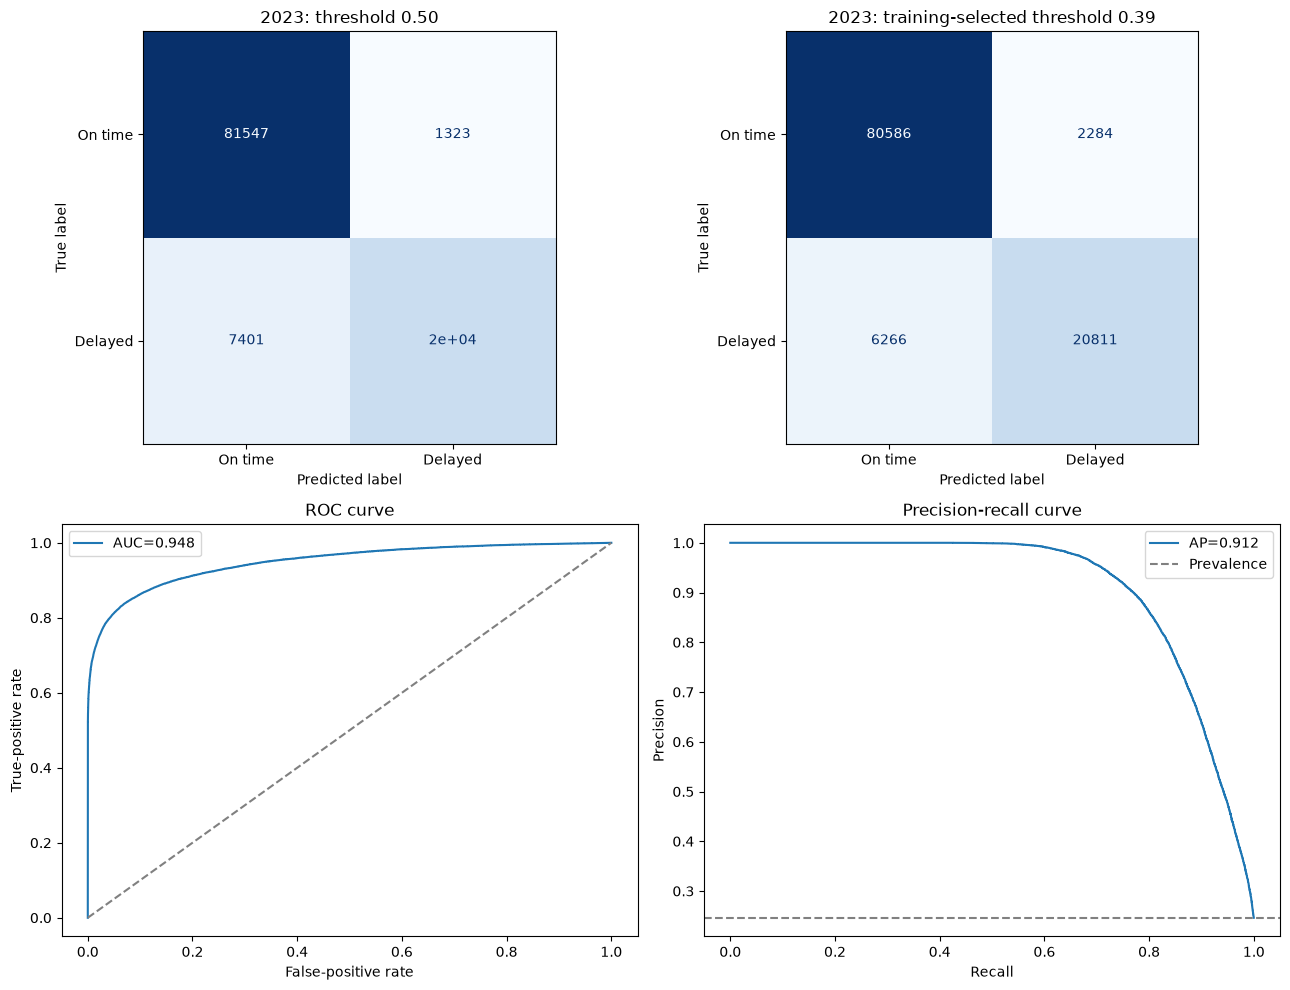

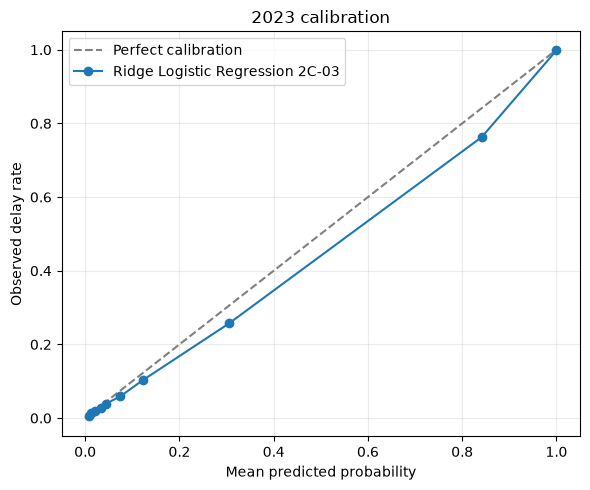

In [8]:
default_predictions = (validation_probabilities >= 0.50).astype(int)
selected_predictions = (validation_probabilities >= selected_threshold).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_validation, validation_probabilities
)
curve_precision, curve_recall, _ = precision_recall_curve(
    y_validation, validation_probabilities
)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    default_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 0],
)
axes[0, 0].set_title("2023: threshold 0.50")
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    selected_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title(
    f"2023: training-selected threshold {selected_threshold:.2f}"
)
axes[1, 0].plot(
    false_positive_rate,
    true_positive_rate,
    label=f"AUC={roc_auc_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].set(
    xlabel="False-positive rate",
    ylabel="True-positive rate",
    title="ROC curve",
)
axes[1, 0].legend()
axes[1, 1].plot(
    curve_recall,
    curve_precision,
    label=f"AP={average_precision_score(y_validation, validation_probabilities):.3f}",
)
axes[1, 1].axhline(
    y_validation.mean(), linestyle="--", color="gray", label="Prevalence"
)
axes[1, 1].set(
    xlabel="Recall",
    ylabel="Precision",
    title="Precision-recall curve",
)
axes[1, 1].legend()
fig.tight_layout()
plt.show()

predicted, observed = calibration_curve(
    y_validation, validation_probabilities, n_bins=10, strategy="quantile"
)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(predicted, observed, marker="o", label="Ridge Logistic Regression 2C-03")
ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed delay rate",
    title="2023 calibration",
)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Inspect coefficients and publishable values

L2 regularization retains all prepared coefficients but shrinks them toward zero. Coefficients are comparable only within this imputed and standardized design. Individual spline-basis coefficients describe ranges of the schedule margin rather than separate operational effects.

In [9]:
preprocessor = best_pipeline.named_steps["preprocessor"]
classifier = best_pipeline.named_steps["classifier"]
prepared_feature_names = preprocessor.get_feature_names_out()
coefficient_table = (
    pd.DataFrame({
        "feature": prepared_feature_names,
        "coefficient": classifier.coef_[0],
    })
    .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .reset_index(drop=True)
)
display(coefficient_table.head(25))
display(
    coefficient_table[
        coefficient_table["feature"].str.contains(
            "TaxiOut|MINUTES_TO_SCHEDULED_ARRIVAL", regex=True
        )
    ]
)

default = evaluation_results.loc[
    "Ridge Logistic Regression 2C-03 (default)"
]
selected = evaluation_results.loc[
    "Ridge Logistic Regression 2C-03 (training-selected)"
]
publishable_summary = pd.Series({
    "selected representation": "raw_taxi_margin_spline",
    "saved source fields": len(SOURCE_FEATURES),
    "calculated model-side fields": 1,
    "prepared predictors": len(prepared_feature_names),
    "selected C": search.best_params_["classifier__C"],
    "selected penalty": "l2",
    "selected solver": "lbfgs",
    "selected class weighting": str(
        search.best_params_["classifier__class_weight"]
    ),
    "training CV AP": search.best_score_,
    "validation prevalence": y_validation.mean(),
    "validation AP": default["average_precision"],
    "validation ROC AUC": default["roc_auc"],
    "validation Brier": default["brier_score"],
    "selected threshold": selected_threshold,
    "selected-threshold accuracy": selected["accuracy"],
    "selected-threshold balanced accuracy": selected["balanced_accuracy"],
    "selected-threshold precision": selected["precision"],
    "selected-threshold recall": selected["recall"],
    "selected-threshold F1": selected["f1"],
    "selected-threshold MCC": selected["mcc"],
    "search seconds": search_seconds,
    "final fit seconds": final_fit_seconds,
}, name="Logistic Regression 2C Experiment 03 Appendix F values")
publishable_summary.to_frame()

,feature,coefficient,abs_coefficient
0,numeric__DepDelay,4.5895,4.5895
1,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,2.3580,2.3580
2,numeric__SCHEDULED_SPEED_PROXY,1.2238,1.2238
3,numeric__CRSElapsedTime,1.0081,1.0081
4,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,0.9451,0.9451
5,numeric__TaxiOut,0.8101,0.8101
6,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,-0.7388,0.7388
7,categorical__Origin_CLT,-0.6392,0.6392
8,categorical__Origin_SJU,0.5946,0.5946
9,numeric__LOG_DISTANCE,0.5901,0.5901


,feature,coefficient,abs_coefficient
1,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,2.3580,2.3580
4,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,0.9451,0.9451
5,numeric__TaxiOut,0.8101,0.8101
6,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,-0.7388,0.7388
13,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,-0.4091,0.4091
24,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,-0.1956,0.1956
61,schedule_margin__MINUTES_TO_SCHEDULED_ARRIVAL_...,0.0588,0.0588


,Logistic Regression 2C Experiment 03 Appendix F values
selected representation,raw_taxi_margin_spline
saved source fields,31
calculated model-side fields,1
prepared predictors,108
selected C,0.0100
selected penalty,l2
selected solver,lbfgs
selected class weighting,None
training CV AP,0.9066
validation prevalence,0.2463


## Interpretation checklist

1. Does ridge logistic regression improve 2019 temporal average precision over the L1 Experiment 02 result?
2. Does any training gain persist in 2023 ranking, probability quality, F1, or MCC?
3. Does balanced class weighting help ranking enough to offset its effect on calibration?
4. Is the difference large enough to replace the sparse L1 model?
5. Keep the existing feature dataset unchanged and keep 2024 untouched.